=== Classification Report ===
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.82      0.90      0.86        10
 Iris-virginica       0.89      0.80      0.84        10

       accuracy                           0.90        30
      macro avg       0.90      0.90      0.90        30
   weighted avg       0.90      0.90      0.90        30



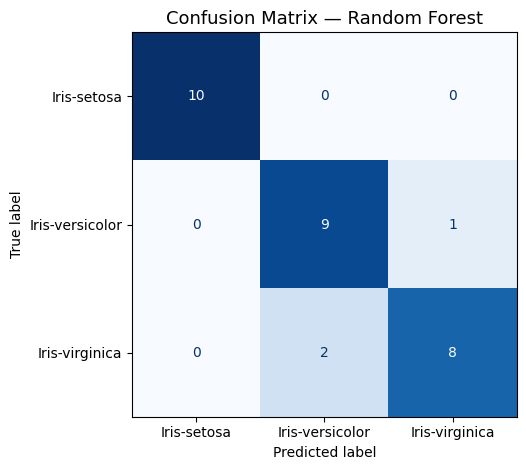

In [8]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

best = models['Random Forest']
y_pred = best.predict(X_test)

# Full classification report
print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion matrix plot
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(cmap='Blues', colorbar=False)
plt.title('Confusion Matrix — Random Forest', fontsize=13)
plt.tight_layout(); plt.show()

KNN                  → Accuracy: 100.00%
Decision Tree        → Accuracy: 93.33%
Random Forest        → Accuracy: 90.00%


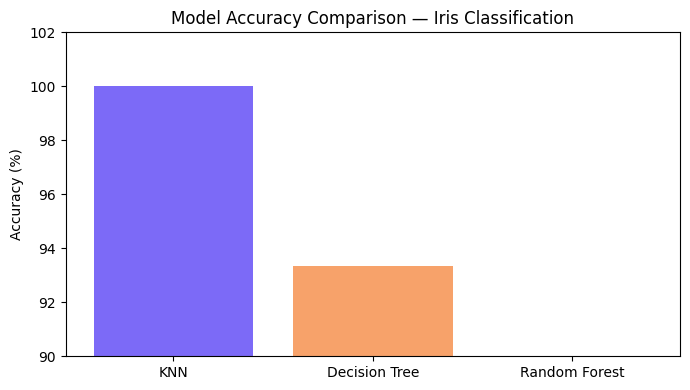

In [7]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

models = {
    'KNN':           KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    results[name] = acc
    print(f"{name:20s} → Accuracy: {acc*100:.2f}%")

# Bar chart comparing models
plt.figure(figsize=(7, 4))
plt.bar(results.keys(), [v*100 for v in results.values()],
        color=['#7c6af7', '#f7a26a', '#6af7c4'])
plt.ylim([90, 102])
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy Comparison — Iris Classification')
plt.tight_layout(); plt.show()

In [6]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Features and target
X = df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]
le = LabelEncoder()
y = le.fit_transform(df['Species'])   # converts species names → 0, 1, 2

# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")
print(f"Classes: {le.classes_}")

Training samples: 120
Testing samples:  30
Classes: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


       SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count     150.000000    150.000000     150.000000    150.000000
mean        5.843333      3.054000       3.758667      1.198667
std         0.828066      0.433594       1.764420      0.763161
min         4.300000      2.000000       1.000000      0.100000
25%         5.100000      2.800000       1.600000      0.300000
50%         5.800000      3.000000       4.350000      1.300000
75%         6.400000      3.300000       5.100000      1.800000
max         7.900000      4.400000       6.900000      2.500000

Missing values:
 SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


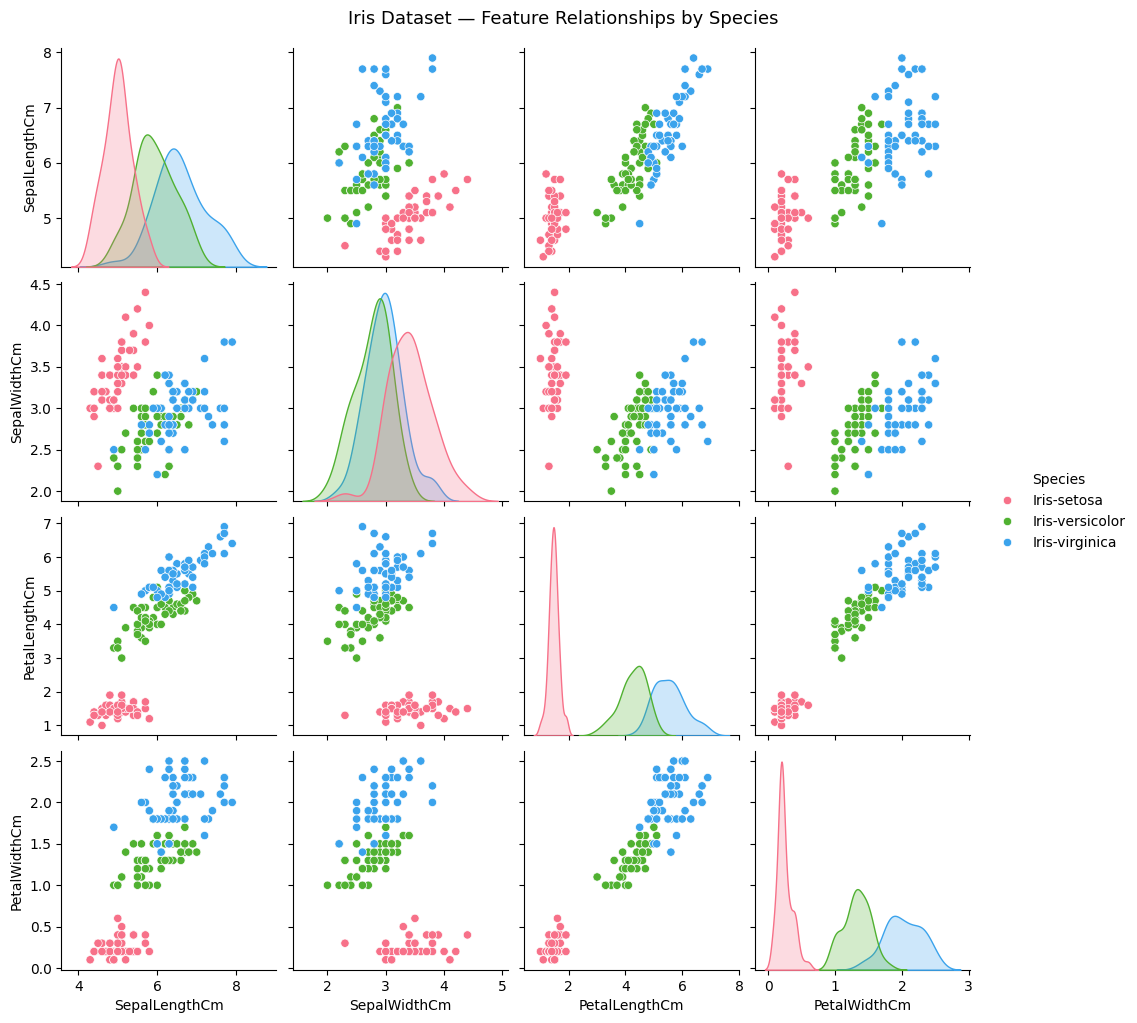

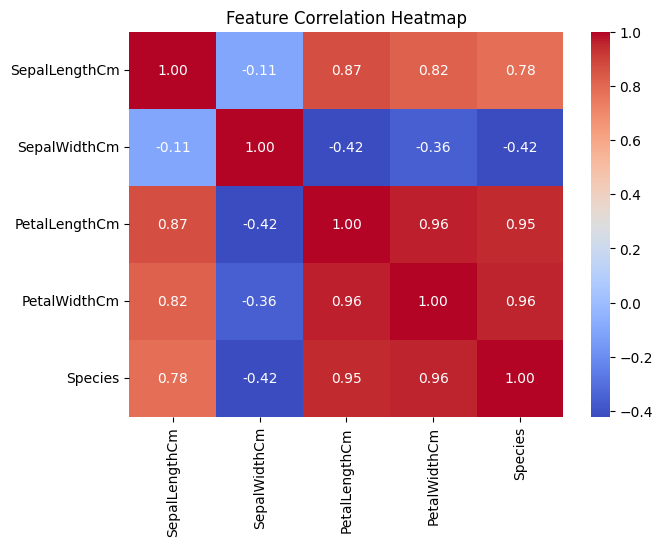

In [5]:
# Basic statistics
print(df.describe())
print("\nMissing values:\n", df.isnull().sum())

# Pairplot — shows how features separate the 3 species
sns.pairplot(df, hue='Species', palette='husl', diag_kind='kde')
plt.suptitle('Iris Dataset — Feature Relationships by Species', y=1.02, fontsize=13)
plt.show()

# Correlation heatmap (encode species first)
df_encoded = df.copy()
df_encoded['Species'] = df_encoded['Species'].map({
    'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2
})
plt.figure(figsize=(7, 5))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the dataset (make sure Iris.csv is uploaded)
df = pd.read_csv('Iris.csv')

# Drop the Id column — it has no predictive value
df.drop('Id', axis=1, inplace=True)

print(df.head())
print("\nShape:", df.shape)
print("\nSpecies counts:\n", df['Species'].value_counts())

   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0            5.1           3.5            1.4           0.2  Iris-setosa
1            4.9           3.0            1.4           0.2  Iris-setosa
2            4.7           3.2            1.3           0.2  Iris-setosa
3            4.6           3.1            1.5           0.2  Iris-setosa
4            5.0           3.6            1.4           0.2  Iris-setosa

Shape: (150, 5)

Species counts:
 Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [2]:
pip install pandas scikit-learn matplotlib seaborn --quiet
